# Detecção de Fraude em Cartões de Crédito
## Um pipeline completo de Machine Learning

**Objetivo:** Construir um sistema de detecção de transações fraudulentas
usando um pipeline end-to-end com scikit-learn, abordando o principal
desafio do problema: o desbalanceamento extremo de classes.

**Dataset:** [Credit Card Fraud Detection — Kaggle (ULB)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- 284.807 transações | 492 fraudes (0,17%)
- Features V1–V28: componentes PCA anonimizados
- Features originais: `Time`, `Amount`, `Class`

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
DATA_PATH = '../data/raw/creditcard.csv'


In [180]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nValores nulos:\n{df.isnull().sum().sum()} (total)")
print(f"\nTipos de dados:\n{df.dtypes.value_counts()}")

df.head()

Shape: (284807, 31)
Memória: 67.4 MB

Valores nulos:
0 (total)

Tipos de dados:
float64    30
int64       1
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [181]:
checks = {
    "Sem valores nulos": df.isnull().sum().sum() == 0,
    "Coluna target existe": 'Class' in df.columns,
    "Target é binário": df['Class'].nunique() == 2,
    "Features numéricas": df.select_dtypes(include=np.number).shape[1] == df.shape[1],
    "Sem duplicatas": df.duplicated().sum() == 0
}

for check, result in checks.items():
    status = "V" if result else "X"
    print(f"{status} {check}")

fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].mean() * 100

print(f"\nTransações legítimas: {fraud_count[0]:,}")
print(f"Transações fraudulentas: {fraud_count[1]:,}")
print(f"Taxa de fraude: {fraud_pct:.3f}%")

V Sem valores nulos
V Coluna target existe
V Target é binário
V Features numéricas
X Sem duplicatas

Transações legítimas: 284,315
Transações fraudulentas: 492
Taxa de fraude: 0.173%


## 1. O principal problema: classes desbalanceadas

Antes de tudo precisamos entender a natureza do problema.
Em detecção de fraude a grande maioria das transações é legitma e isso cria um problema sério para modelos de Machine Learning que veremos a seguir

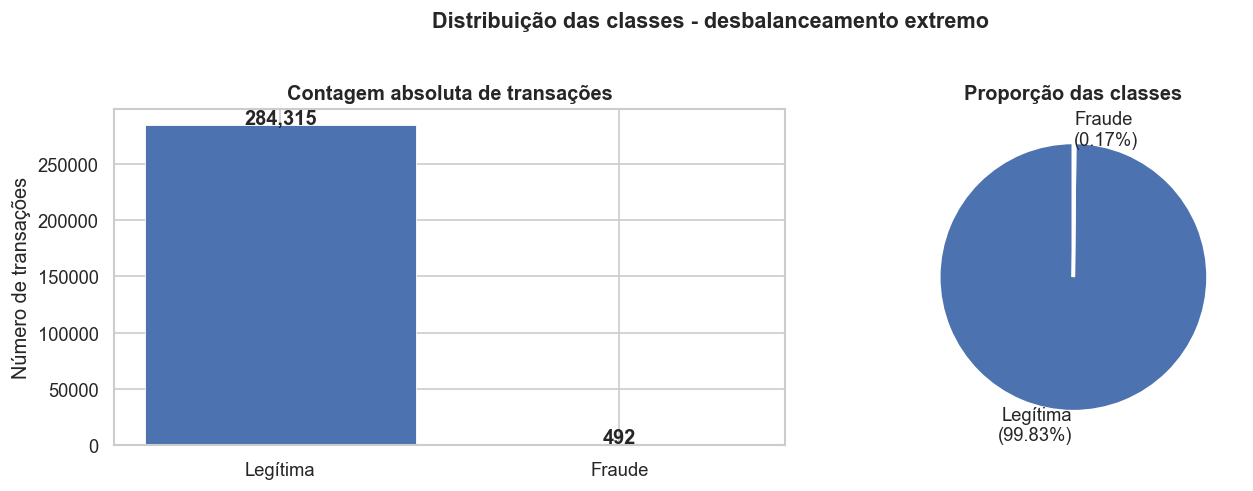


Razão de desbalanceamento: 578:1
Para cada fraude, há 578 transações legítimas


In [182]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# grafico contagem absoluta
class_counts = df['Class'].value_counts()
colors = ['#4C72B0', '#DD5A5A']

axes[0].bar(['Legítima', 'Fraude'], class_counts.values, color=colors,
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Contagem absoluta de transações', fontweight='bold')
axes[0].set_ylabel('Número de transações')

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# grafico proporção
axes[1].pie(
    class_counts.values,
    labels=['Legítima\n(99.83%)', 'Fraude\n(0.17%)'],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporção das classes', fontweight='bold')

plt.suptitle('Distribuição das classes - desbalanceamento extremo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRazão de desbalanceamento: {class_counts[0]/class_counts[1]:.0f}:1")
print(f"Para cada fraude, há {class_counts[0]/class_counts[1]:.0f} transações legítimas")

### Insight Importante!!

Com 0.17% de fraudes, um modelo que simplesmente classifica tudo como **legítimo** alcança 99.83% de accuracy, isso é inútil.

Isso significa que a accuracy não pode ser a métrica principal.
Usaremos **Precision-Recall AUC**, que é robusta e desbalanceamento.

Além disso, precisaremos de uma estratégia para lidar com o desbalanceamento
durante o treinamento.

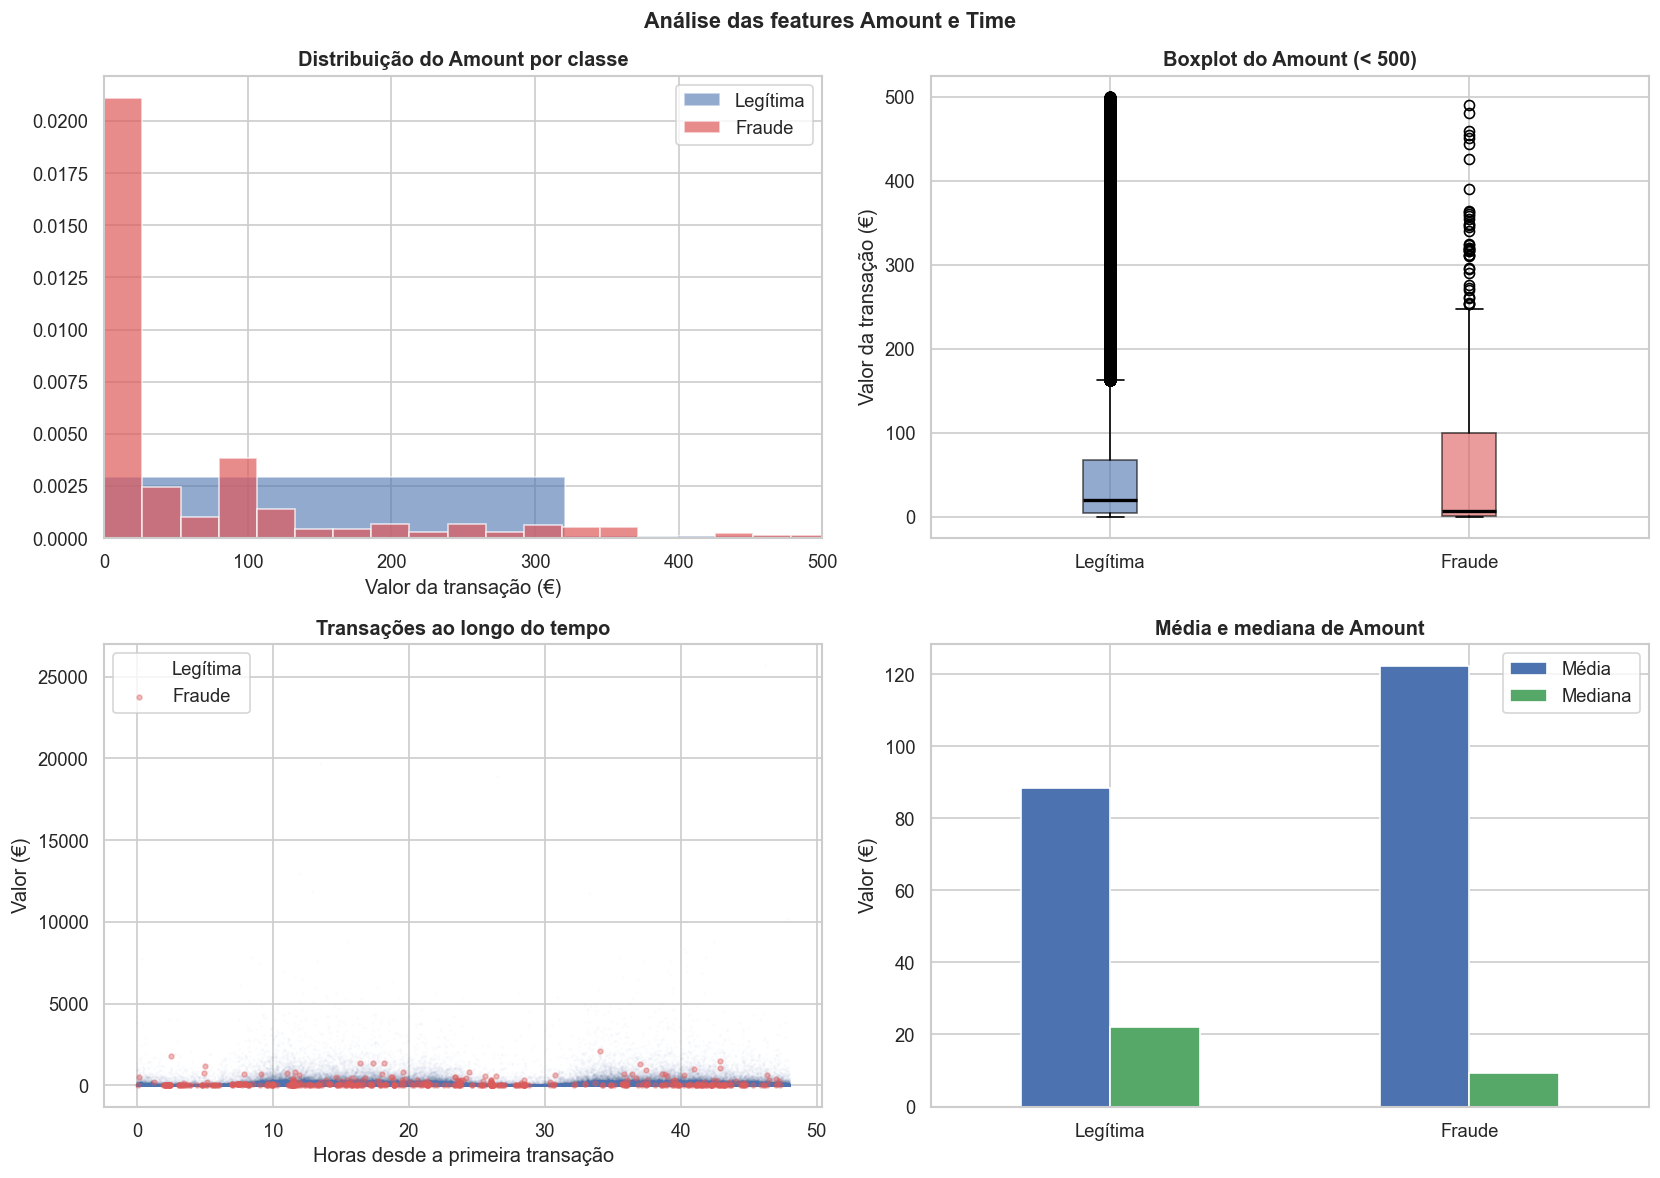

Estatísticas do Amount por classe:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [183]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# distribuição por classe - amount
axes[0, 0].hist(legit['Amount'], bins=80, alpha=0.6,
                color='#4C72B0', label='Legítima', density=True)
axes[0, 0].hist(fraud['Amount'], bins=80, alpha=0.7,
                color='#DD5A5A', label='Fraude', density=True)
axes[0, 0].set_xlim(0, 500)
axes[0, 0].set_title('Distribuição do Amount por classe', fontweight='bold')
axes[0, 0].set_xlabel('Valor da transação (€)')
axes[0, 0].legend()

# boxplot de comparação - amount
legit_small = legit[legit['Amount'] < 500]['Amount']
fraud_small = fraud[fraud['Amount'] < 500]['Amount']

bp = axes[0, 1].boxplot(
    [legit_small, fraud_small],
     labels=['Legítima', 'Fraude'],
     patch_artist=True,
     medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set(facecolor='#4C72B0', alpha=0.6)
bp['boxes'][1].set(facecolor='#DD5A5A', alpha=0.6)
axes[0, 1].set_title('Boxplot do Amount (< 500)', fontweight='bold')
axes[0, 1].set_ylabel('Valor da transação (€)')

# fraudes ao longo do tempo - Time
axes[1, 0].scatter(legit['Time'] / 3600, legit['Amount'],
                   alpha=0.01, s=1, color='#4C72B0', label='Legítima')
axes[1, 0].scatter(fraud['Time'] / 3600, fraud['Amount'],
                   alpha=0.4, s=8, color='#DD5A5A', label='Fraude', zorder=5)
axes[1, 0].set_title('Transações ao longo do tempo', fontweight='bold')
axes[1, 0].set_xlabel('Horas desde a primeira transação')
axes[1, 0].set_ylabel('Valor (€)')
axes[1, 0].legend()

# fraude vs legítimo - amount media e mediana
stats = df.groupby('Class')['Amount'].agg(['mean', 'median'])
stats.index = ['Legítima', 'Fraude']
stats.plot(kind='bar', ax=axes[1, 1], color=['#4C72B0', '#55A868'],
           edgecolor='white', rot=0)
axes[1, 1].set_title('Média e mediana de Amount', fontweight='bold')
axes[1, 1].set_ylabel('Valor (€)')
axes[1, 1].legend(['Média', 'Mediana'])

plt.suptitle('Análise das features Amount e Time',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/amount_time_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# estatisticas descritivas
print("Estatísticas do Amount por classe:")
print(df.groupby('Class')['Amount'].describe().round(2))

### Insights sobre *Amount* e *Time*

As fraudes tendem a ocorrer em **valores mais baixos** (mediana ~€22, contra ~€55 nas transações legítimas).
  Esse comportamento é consistente com o padrão de *card testing*, em que criminosos realizam pequenas compras para validar o cartão antes de tentar valores maiores.

Observam-se **dois picos de atividade ao longo do tempo** (~12h e ~36h), provavelmente refletindo dois ciclos diários no conjunto de dados.
  As fraudes estão presentes em ambos os períodos, sem concentração exclusiva em um intervalo específico.

As variáveis `Amount` e `Time` devem passar por **normalização**, já que são as únicas que não foram transformadas por PCA.


Top 10 features mais correlacionadas com fraude:
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


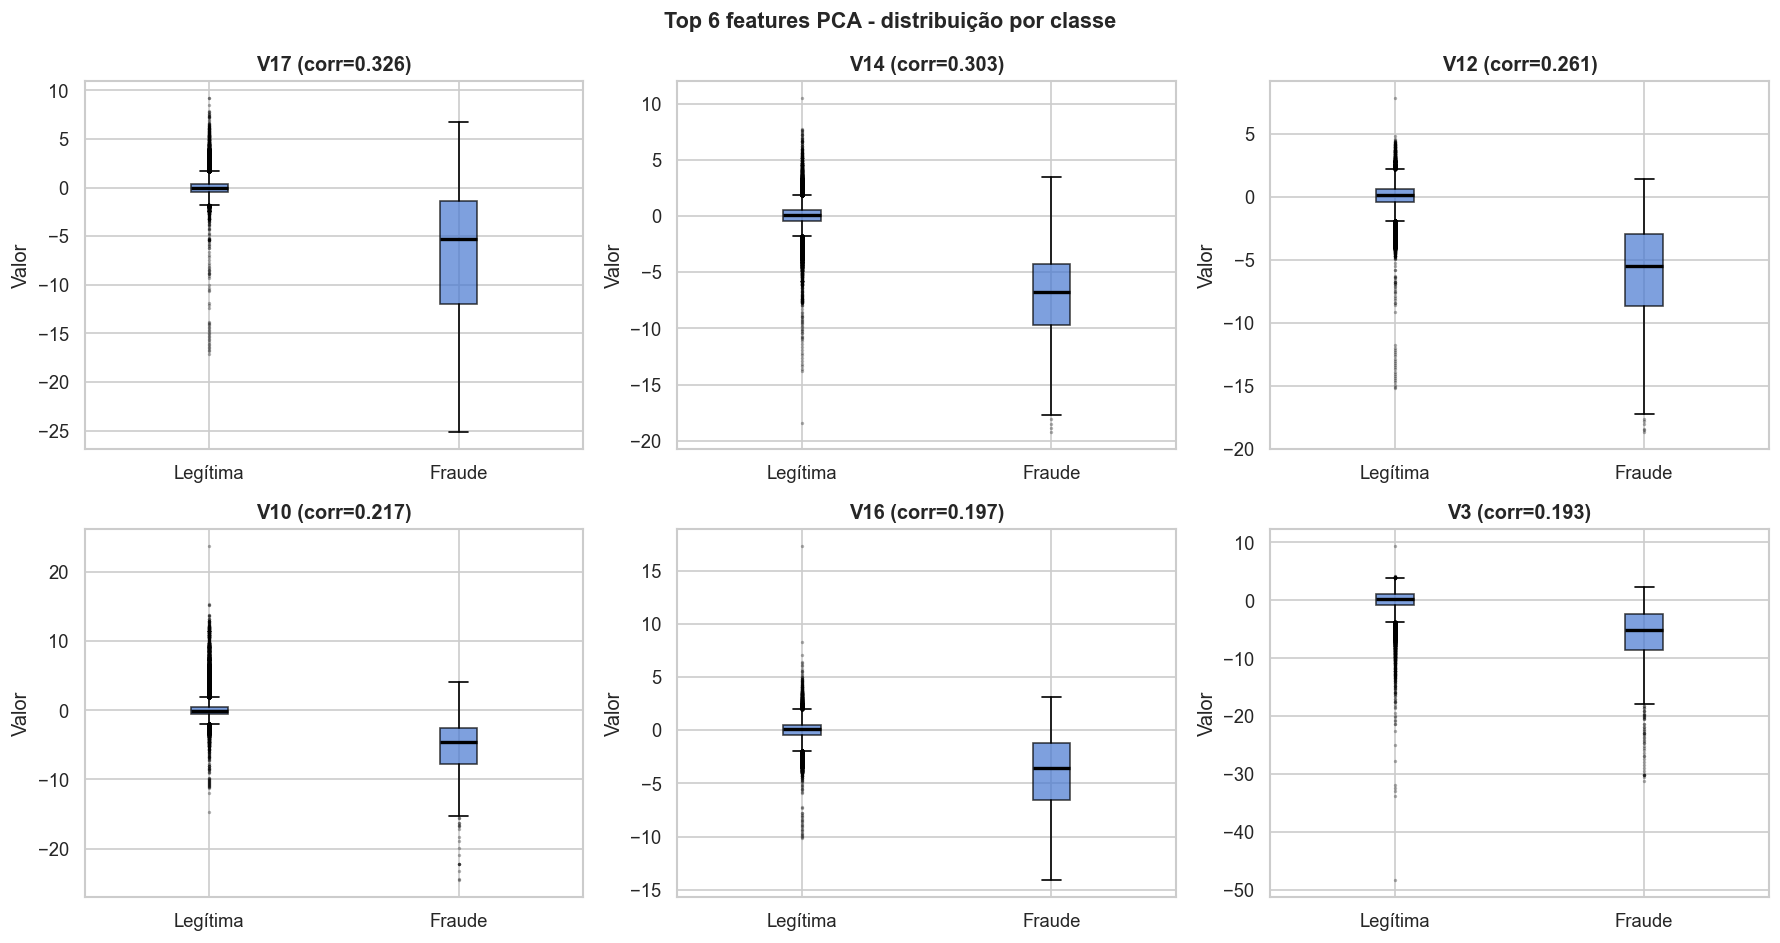

In [184]:
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

print("Top 10 features mais correlacionadas com fraude:")
print(correlations.head(10).round(4))

# boxplots das features - top 6
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

top6 = correlations.head(6).index.tolist()

for i, feature in enumerate(top6):
    data_legit = legit[feature]
    data_fraud = fraud[feature]

    axes[i].boxplot(
        [data_legit, data_fraud],
        labels=['Legítima', 'Fraude'],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )
    axes[i].set_title(f'{feature} (corr={correlations[feature]:.3f})',
                      fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Top 6 features PCA - distribuição por classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/top_features_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

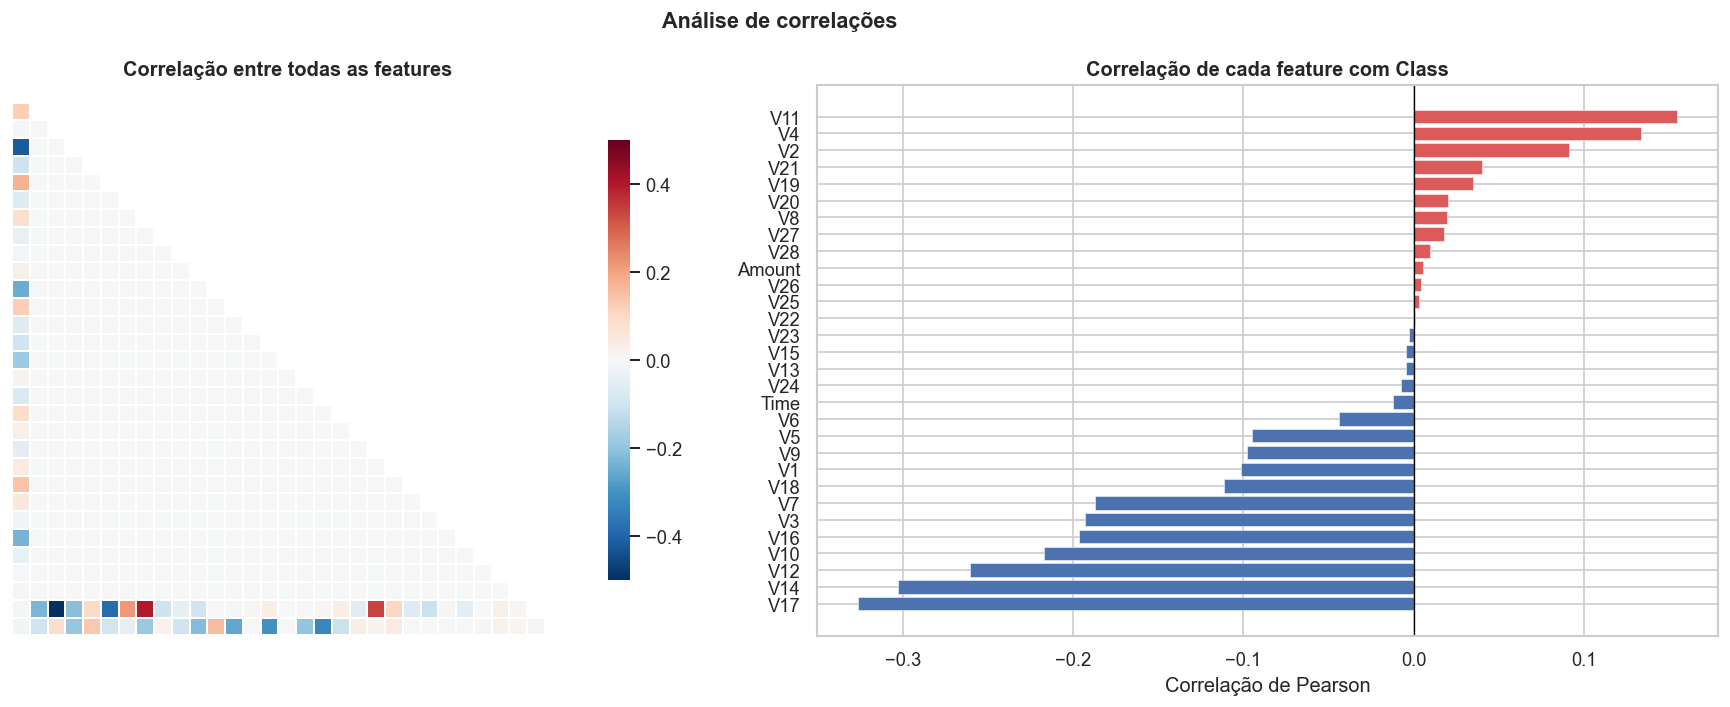

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# heatmap completo
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=axes[0],
    cmap='RdBu_r',
    center=0,
    vmin= -0.5, vmax=0.5,
    square=True,
    linewidths=0.1,
    cbar_kws={'shrink': 0.8},
    xticklabels=False,
    yticklabels=False
)
axes[0].set_title('Correlação entre todas as features', fontweight='bold')

# correlação com target
target_corr = corr_matrix['Class'].drop('Class').sort_values()

colors_bar = ['#DD5A5A' if x > 0 else '#4C72B0' for x in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Correlação de cada feature com Class', fontweight='bold')
axes[1].set_xlabel('Correlação de Pearson')

plt.suptitle('Análise de correlações', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Síntese da EDA — direcionamentos para as próximas etapas

| Achado                                  | Decisão técnica                                                              |
| --------------------------------------- | ---------------------------------------------------------------------------- |
| Forte desbalanceamento (577:1)          | Aplicar SMOTE no conjunto de treino e utilizar PR-AUC como métrica principal |
| `Amount` e `Time` sem normalização      | Incluir `StandardScaler` no pipeline de pré-processamento                    |
| Features PCA já normalizadas            | Evitar aplicação de scaler nas variáveis V1–V28                              |
| V14, V17 e V12 com maior correlação     | Acompanhar a importância dessas features no modelo final                     |
| Fraudes concentradas em valores menores | A variável `Amount` apresenta bom potencial preditivo                        |


## Pré-processamento e Feature Engineering

A EDA revelou dois problemas que precisamos resolver antes de treinar
qualquer modelo:

1. `Amount` e `Time` estão em escalas completamente diferentes das features PCA
2. O desbalanceamento 577:1 vai enviesar qualquer modelo treinado ingenuamente

Vamos resolver os dois de forma reproduzível usando um `Pipeline` do scikit-learn,
garantindo que **nenhum vazamento de dados** ocorra entre treino e teste.

In [186]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImPipeline
from imblearn.over_sampling import SMOTE

In [187]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y      # <- para garantir a mesma proporção de fraudes em treino e teste
)

# verificar a estratificação
train_fraud_pct = y_train.mean() * 100
test_fraud_pct = y_test.mean() * 100

print(f"Treino:  {X_train.shape[0]:,} amostras | fraudes: {train_fraud_pct:.3f}%")
print(f"Teste:  {X_test.shape[0]:,} amostras | fraudes: {test_fraud_pct:.3f}%")
print(f"\nProporção preservada: {'✓' if abs(train_fraud_pct - test_fraud_pct) < 0.01 else '✗'}")

Treino:  227,845 amostras | fraudes: 0.173%
Teste:  56,962 amostras | fraudes: 0.172%

Proporção preservada: ✓


In [188]:
SCALE_FEATURES = ['Amount', 'Time']

In [189]:
# scaler ajustado no treino apenas
scaler_viz = StandardScaler()
scaler_viz.fit(X_train[SCALE_FEATURES])

amount_original = X_train['Amount'].values
amount_scaled = scaler_viz.transform(X_train[SCALE_FEATURES])[:, 0]

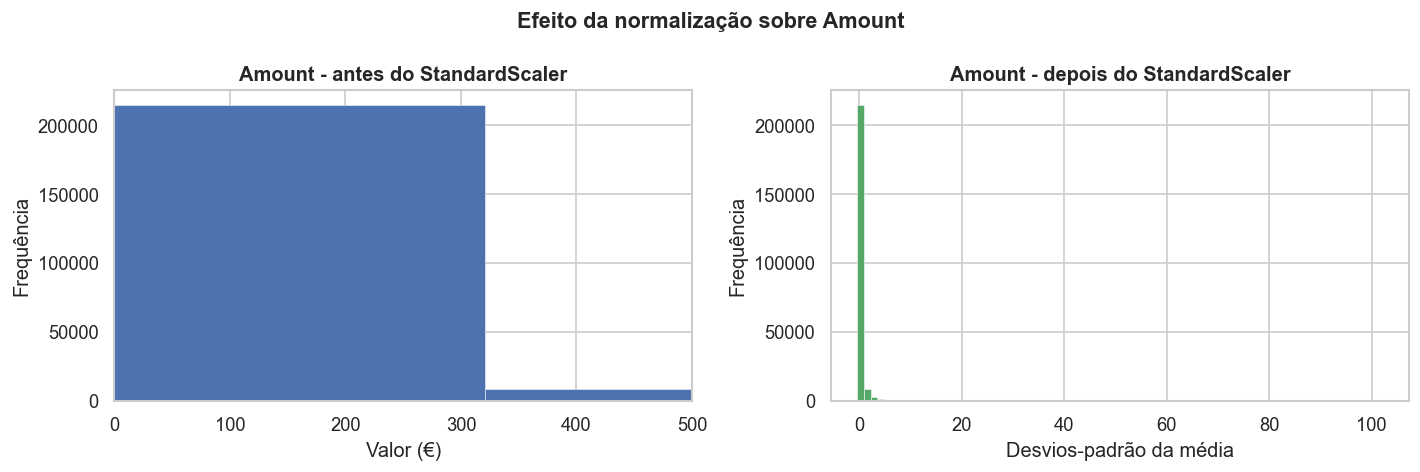

Antes - média: 88.18 | std: 250.72
Depois - média: 0.0000 | std: 1.0000


In [190]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# antes da normalização
axes[0].hist(amount_original, bins=80, color='#4C72B0',
            edgecolor='white', linewidth=0.3)
axes[0].set_title('Amount - antes do StandardScaler', fontweight='bold')
axes[0].set_xlabel('Valor (€)')
axes[0].set_ylabel('Frequência')
axes[0].set_xlim(0, 500)

# depois da normalização
axes[1].hist(amount_scaled, bins=80, color='#55A868',
             edgecolor='white', linewidth=0.3)
axes[1].set_title('Amount - depois do StandardScaler', fontweight='bold')
axes[1].set_xlabel('Desvios-padrão da média')
axes[1].set_ylabel('Frequência')

plt.suptitle('Efeito da normalização sobre Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Antes - média: {amount_original.mean():.2f} | std: {amount_original.std():.2f}")
print(f"Depois - média: {amount_scaled.mean():.4f} | std: {amount_scaled.std():.4f}")

### Por que escalar apenas `Amount` e `Time`?

As features V1–V28 já passaram por PCA durante a anonimização do dataset
elas já estão normalizadas. Aplicar StandardScaler nelas seria redundante
e não traria benefício. Só `Amount` e `Time` precisam de tratamento.

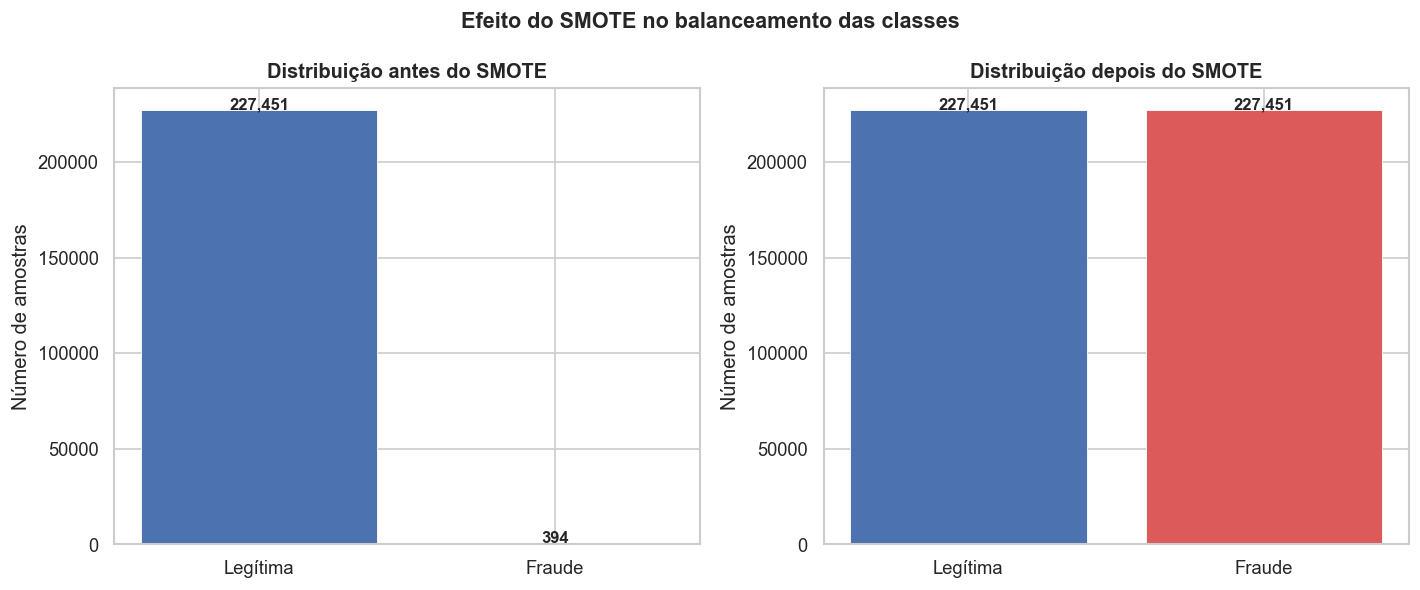

Antes - legítima: 227,451 | fraude: 394
Depois - legítima: 227,451 | fraude: 227,451


In [191]:
# preprocessor e SMOTE para demonstração visual
preprocessor_viz = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), SCALE_FEATURES)],
    remainder='passthrough'
)
X_train_prep_viz = preprocessor_viz.fit_transform(X_train)
smote_viz = SMOTE(random_state=RANDOM_STATE)
_, y_resampled_viz = smote_viz.fit_resample(X_train_prep_viz, y_train)

# contagens antes e depois
before_counts = y_train.value_counts().sort_index()
after_counts = pd.Series(y_resampled_viz).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Legítima', 'Fraude']
colors = ['#4C72B0', '#DD5A5A']
x_pos = [0, 1]

# antes do SMOTE
bars_before = axes[0].bar(x_pos, before_counts.values,
                          color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_title('Distribuição antes do SMOTE', fontweight='bold')
axes[0].set_ylabel('Número de amostras')

for bar, val in zip(bars_before, before_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
    
# depois do SMOTE
bars_after = axes[1].bar(x_pos, after_counts.values,
                         color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title('Distribuição depois do SMOTE', fontweight='bold')
axes[1].set_ylabel('Número de amostras')

for bar, val in zip(bars_after, after_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Efeito do SMOTE no balanceamento das classes',
             fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Antes - legítima: {before_counts[0]:,} | fraude: {before_counts[1]:,}")
print(f"Depois - legítima: {after_counts[0]:,} | fraude: {after_counts[1]:,}")

### SMOTE só no treino — prevenindo data leakage

O SMOTE **gera amostras sintéticas** interpolando entre exemplos reais de fraude.
Se aplicado antes do split, exemplos sintéticos derivados do teste contaminariam
o treino, o modelo "veria" o teste de forma indireta durante o treinamento.

Usando o `Pipeline` do imbalanced-learn, o SMOTE é aplicado automaticamente
**apenas durante o `.fit()`**, nunca durante o `.predict()` ou `.score()`.

In [192]:
def build_pipeline(model):
    """
    Cria um pipeline completo de pré-processamento, balanceamento e modelagem.

    Este pipeline utiliza o `ImPipeline` do imbalanced-learn para garantir que
    o SMOTE seja aplicado apenas durante o treinamento, evitando vazamento de dados
    (data leakage) no conjunto de teste e em produção.

    Etapas do pipeline:
    -------------------
    1. Pré-processamento:
        - Aplica `StandardScaler` nas features especificadas em `SCALE_FEATURES`
        - Mantém as demais variáveis inalteradas

    2. Balanceamento:
        - Aplica SMOTE para lidar com desbalanceamento de classes
    
    3. Modelagem:
        - Treina o modelo fornecido como parâmetro
    
    Parâmetros
    ----------
    model : sklearn.base.BaseEstimator
        Modelo a ser utilizado na etapa final do pipeline.

    Retorna
    -------
    imblearn.pipeline.Pipeline
        Pipeline contendo pré-processamento, SMOTE e modelo.
    """

    preprocessor = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), SCALE_FEATURES)],
        remainder='passthrough'
    )

    return ImPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])

# Smoke test - verifica se o pipeline funciona sem erros

from sklearn.linear_model import LogisticRegression

pipeline_test = build_pipeline(LogisticRegression(max_iter=100))
pipeline_test.fit(X_train, y_train)
test_score = pipeline_test.score(X_test, y_test)

print("Pipeline funcionando ✓")
print(f"Accuracy no teste (baseline rápido): {test_score:.4f}")
print(f"Etapas: {[step[0] for step in pipeline_test.steps]}")

Pipeline funcionando ✓
Accuracy no teste (baseline rápido): 0.9742
Etapas: ['preprocessor', 'smote', 'model']


## Resumo

A função `build_pipeline(model)` encapsula toda a lógica de pré-processamento
e pode ser reutilizada com qualquer estimador do scikit-learn:

| Etapa | Componente | Responsabilidade |
|-------|-----------|-----------------|
| 1 | `ColumnTransformer` | Normaliza `Amount` e `Time`; mantém V1–V28 intactos |
| 2 | `SMOTE` | Balanceia classes apenas no treino |
| 3 | `model` | Plugável — será definido na Fase 4 |

In [193]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
import joblib

In [194]:
# paleta de cores para os gráficos
COLORS = {
    'Logistic Regression': '#4C72B0',
    'Random Forest': '#55A868',
    'XGBoost': '#DD5A5A'
}

print('libs e cores carregados ✓')

libs e cores carregados ✓


## 4. Treinamento e comparação de modelos

Vamos avaliar três modelos com complexidades distintas para entender
o trade-off entre interpretabilidade e performance:

- **Logistic Regression** — baseline linear, rápido e interpretável
- **Random Forest** — ensemble robusto, lida bem com features PCA
- **XGBoost** — gradient boosting, geralmente superior em dados tabulares

Cada modelo será encapsulado em `build_pipeline()` para garantir que
o pré-processamento seja idêntico para todos.

In [195]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,    # <- antes era 100
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric='aucpr',
        verbosity=0,
        n_jobs=-1
    )
}

print("Modelos definidos:")
for name in models:
    print(f"    ·   {name}")

Modelos definidos:
    ·   Logistic Regression
    ·   Random Forest
    ·   XGBoost


### Cross-validation com StratifiedKFold

Usamos 5 folds estratificados para garantir que cada fold contenha
fraudes. Avaliamos duas métricas:

- **PR-AUC** (métrica principal) — robusta ao desbalanceamento
- **ROC-AUC** (métrica secundária) — referência clássica de comparação

In [196]:
SCORING = {
    'pr_auc':  'average_precision',
    'roc_auc': 'roc_auc',
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)   # <- antes era n_splits=5

cv_results = {}

for name, model in models.items():
    print(f"Treinando {name}...", end=' ')

    pipeline = build_pipeline(model)
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results[name] = {
        'pr_auc_mean': scores['test_pr_auc'].mean(),
        'pr_auc_std': scores['test_pr_auc'].std(),
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'roc_auc_std': scores['test_roc_auc'].std()
    }

    print(f"PR-AUC: {cv_results[name]['pr_auc_mean']:.4f} "
          f"(±{cv_results[name]['pr_auc_std']:.4f})")
    
print("\n✓ Cross-validation concluído")

Treinando Logistic Regression... PR-AUC: 0.7482 (±0.0241)
Treinando Random Forest... PR-AUC: 0.8235 (±0.0276)
Treinando XGBoost... PR-AUC: 0.8409 (±0.0269)

✓ Cross-validation concluído


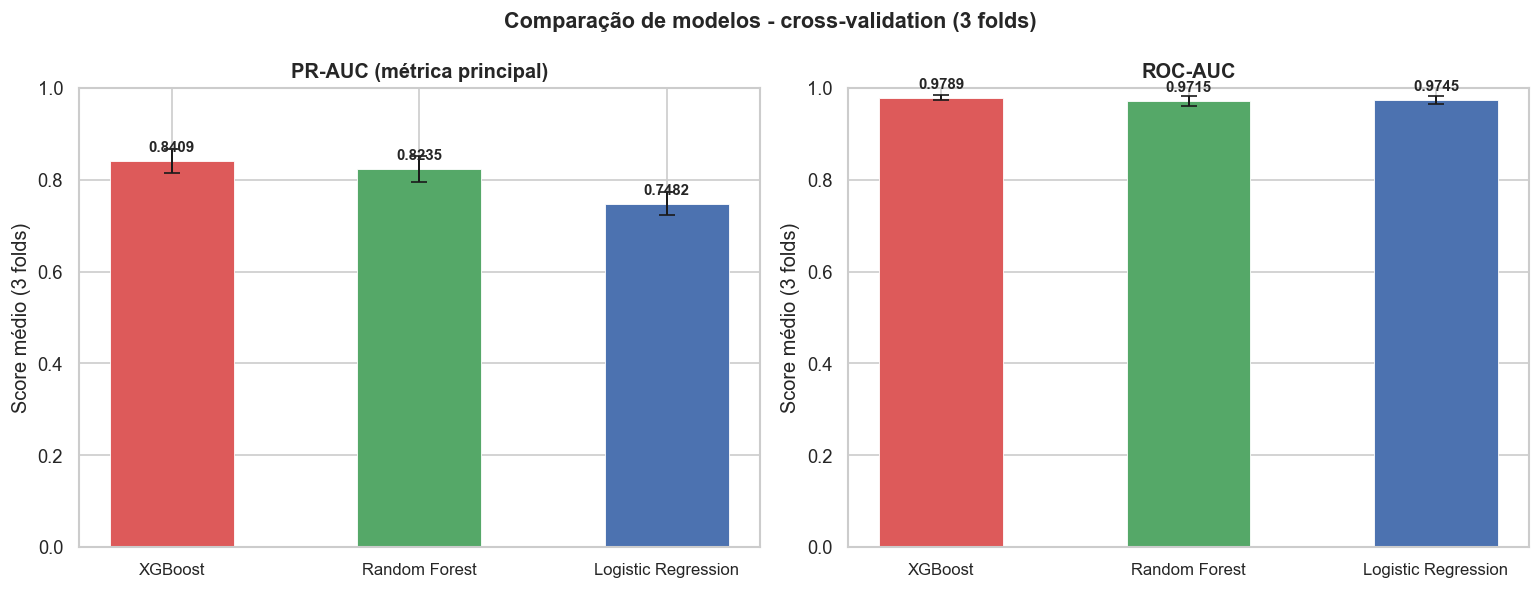


Resultados completos:
              model  pr_auc_mean  pr_auc_std  roc_auc_mean  roc_auc_std
            XGBoost     0.840873    0.026890      0.978892     0.005373
      Random Forest     0.823497    0.027649      0.971538     0.011814
Logistic Regression     0.748212    0.024132      0.974456     0.008967

✓ Melhor modelo: XGBoost


In [197]:
results_df = pd.DataFrame(cv_results).T.reset_index()
results_df.columns = ['model', 'pr_auc_mean', 'pr_auc_std',
                      'roc_auc_mean', 'roc_auc_std']
results_df = results_df.sort_values('pr_auc_mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_pos = range(len(results_df))
bar_width = 0.5

for ax, metric, label in [
    (axes[0], 'pr_auc', 'PR-AUC (métrica principal)'),
    (axes[1], 'roc_auc', 'ROC-AUC')
]:
    bars = ax.bar(
        x_pos,
        results_df[f'{metric}_mean'],
        yerr=results_df[f'{metric}_std'],
        width=bar_width,
        color=[COLORS[m] for m in results_df['model']],
        edgecolor='white',
        linewidth=0.5,
        capsize=5,
        error_kw={'linewidth': 1.2}
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['model'], fontsize=10)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Score médio (3 folds)')
    ax.set_ylim(0, 1)

    for bar, mean_val in zip(bars, results_df[f'{metric}_mean']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{mean_val:.4f}',
            ha='center', fontsize=9, fontweight='bold'
        )

plt.suptitle('Comparação de modelos - cross-validation (3 folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# tabela de resultados

print("\nResultados completos:")
print(results_df.to_string(index=False))

# seleciona o melhor modelo
best_model_name = results_df.iloc[0]['model']
print(f"\n✓ Melhor modelo: {best_model_name}")


### Por que o XGBoost vence?

O XGBoost usa **gradient boosting** constrói árvores sequencialmente,
cada uma corrigindo os erros da anterior. Essa abordagem é especialmente
eficaz com features PCA porque:

1. Captura relações não-lineares entre componentes
2. O boosting naturalmente dá mais peso a exemplos difíceis (fraudes)
3. Regularização L1/L2 embutida previne overfitting

O próximo passo é otimizar seus hiperparâmetros com GridSearchCV.

### Otimização de hiperparâmetros

Aplicamos GridSearchCV apenas no modelo vencedor, otimizar todos
seria custoso e desnecessário para o que estou propondo fazer. Usamos PR-AUC
como critério de seleção, consistente com a escolha de métrica.

In [198]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],     # <- antes estava 'model__max_depth': [3, 5, 7]
    'model__learning_rate': [0.05, 0.1],
    # 'model__subsample': [0.8, 1.0]    # <- subsample removido
}

best_base_pipeline = build_pipeline(models[best_model_name])

grid_search = GridSearchCV(
    estimator=best_base_pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"    {param}: {value}")

print(f"\nMelhor PR-AUC (CV): {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Melhores hiperparâmetros:
    model__learning_rate: 0.1
    model__max_depth: 5
    model__n_estimators: 200

Melhor PR-AUC (CV): 0.8302


In [199]:
# grid_search.best_estimator_ já é o pipeline retreinado no X_train completo
final_pipeline = grid_search.best_estimator_

# salva o modelo
model_path = '../models/best_model.pkl'
joblib.dump(final_pipeline, model_path)
print(f"Modelo salvo em: {model_path}")

# verifica se o modelo carrega e prediz corretamente
loaded_pipeline = joblib.load(model_path)
sample_preds = loaded_pipeline.predict_proba(X_test[:5])[:, 1]

print(f"\nVerificação de carregamento ✓")
print(f"Probabilidades de fraude (5 amostras): {sample_preds.round(4)}")
print(f"\nPróxima etapa: avaliar {best_model_name} otimizado no conjunto de teste.")

Modelo salvo em: ../models/best_model.pkl

Verificação de carregamento ✓
Probabilidades de fraude (5 amostras): [0.0001 0.     0.0001 0.     0.0004]

Próxima etapa: avaliar XGBoost otimizado no conjunto de teste.


> **Nota metodológica:** usamos 3 folds na comparação inicial e uma grid
> reduzida para manter o tempo de execução do notebook razoável.
> Em produção, expandiríamos para 5 folds e uma busca mais ampla,
> possivelmente com RandomizedSearchCV.

todas as modificações estão documentadas no código

## Resumo

| Etapa | Detalhe |
|-------|---------|
| Modelos avaliados | Logistic Regression, Random Forest, XGBoost |
| Estratégia de validação | StratifiedKFold (5 folds) |
| Métrica de seleção | PR-AUC |
| Otimização | GridSearchCV no modelo vencedor |
| Entregável | `models/best_model.pkl` pronto para avaliação |

**Importante:** o conjunto de teste não foi tocado em nenhum momento
desta fase — toda a seleção e otimização ocorreu exclusivamente
sobre os dados de treino.

### Avaliação e interpretabilidade

O modelo foi treinado e otimizado exclusivamente sobre os dados de treino.
Agora avaliamos pela primeira e única vez no conjunto de teste, dados que
o modelo nunca viu em nenhuma etapa anterior.

In [200]:
import shap
from sklearn.metrics import(
    precision_recall_curve,
    roc_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [201]:
# probabilidades e predições com threshold padrão (0.5)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = final_pipeline.predict(X_test)

print("Avaliação com threshold padrão (0.5):")
print(classification_report(y_test, y_pred_default,
                            target_names=['Legítima', 'Fraude'],
                            digits=4))

Avaliação com threshold padrão (0.5):
              precision    recall  f1-score   support

    Legítima     0.9998    0.9982    0.9990     56864
      Fraude     0.4599    0.8776    0.6035        98

    accuracy                         0.9980     56962
   macro avg     0.7298    0.9379    0.8013     56962
weighted avg     0.9989    0.9980    0.9983     56962



### Por que o threshold padrão (0.5) raramente é ideal?

Em detecção de fraude, os custos são assimétricos:
- **Falso Negativo** (deixar fraude passar) → prejuízo financeiro direto
- **Falso Positivo** (bloquear transação legítima) → perda de cliente

O threshold ideal depende do custo relativo desses erros para o negócio.
Vamos explorar como o threshold afeta esse trade-off.

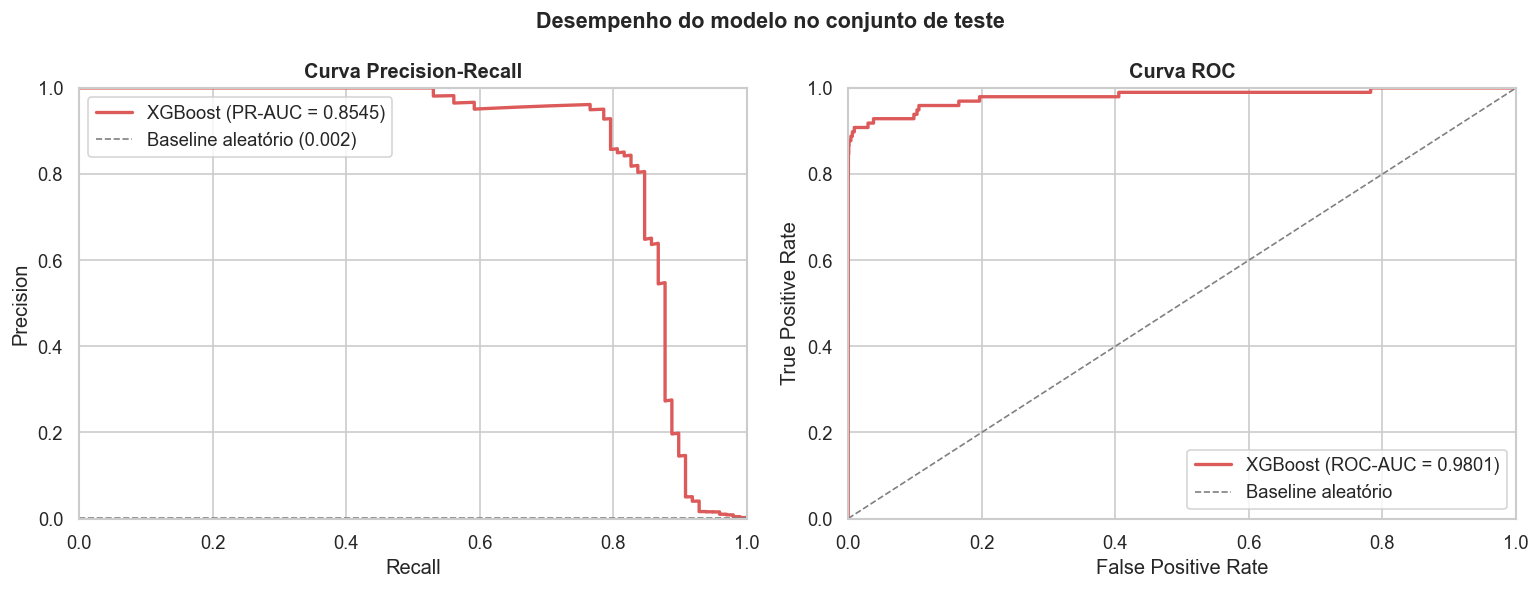

PR-AUC: 0.8545
ROC-AUC: 0.9801


In [202]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# curva precision-recall
axes[0].plot(recall, precision, color=COLORS['XGBoost'],
             linewidth=2, label=f'XGBoost (PR-AUC = {pr_auc:.4f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Baseline aleatório ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# curva ROC
axes[1].plot(fpr, tpr, color=COLORS['XGBoost'],
             linewidth=2, label=f'XGBoost (ROC-AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--',
             linewidth=1, label='Baseline aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('Desempenho do modelo no conjunto de teste',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/pr_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

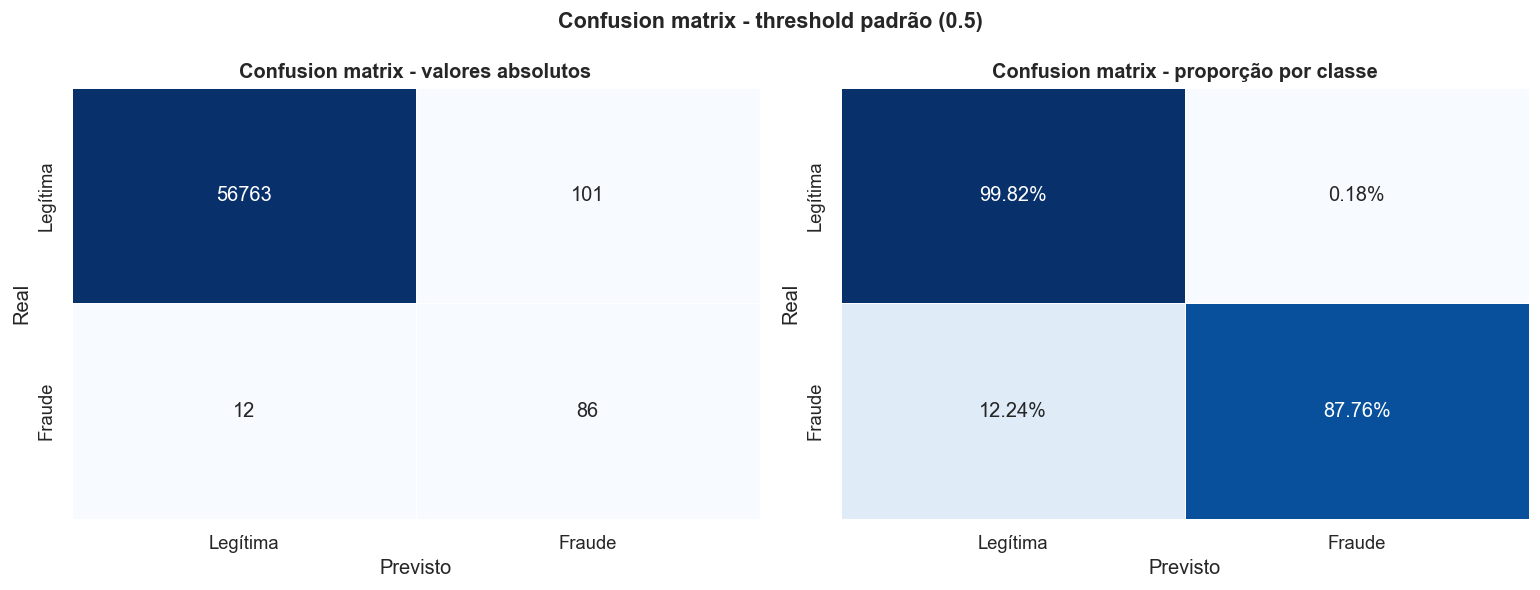

Verdadeiros Negativos (TN): 56,763 - transações legítimas corretamente identificadas
Falsos Positivos (FP): 101 - legítimas bloqueadas incorretamente
Falsos Negativos (FN): 12 - fraudes não detectadas
Verdadeiros Positivos (TP): 86 - fraudes corretamente detectadas


In [203]:
cm = confusion_matrix(y_test, y_pred_default)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# contagem absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'],
            ax=axes[0], linewidths=0.5, cbar=False)
axes[0].set_title('Confusion matrix - valores absolutos', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsto')

# proporção normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'],
            ax=axes[1], linewidths=0.5, cbar=False)
axes[1].set_title('Confusion matrix - proporção por classe', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

plt.suptitle(f'Confusion matrix - threshold padrão (0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros Negativos (TN): {tn:,} - transações legítimas corretamente identificadas")
print(f"Falsos Positivos (FP): {fp:,} - legítimas bloqueadas incorretamente")
print(f"Falsos Negativos (FN): {fn:,} - fraudes não detectadas")
print(f"Verdadeiros Positivos (TP): {tp:,} - fraudes corretamente detectadas")

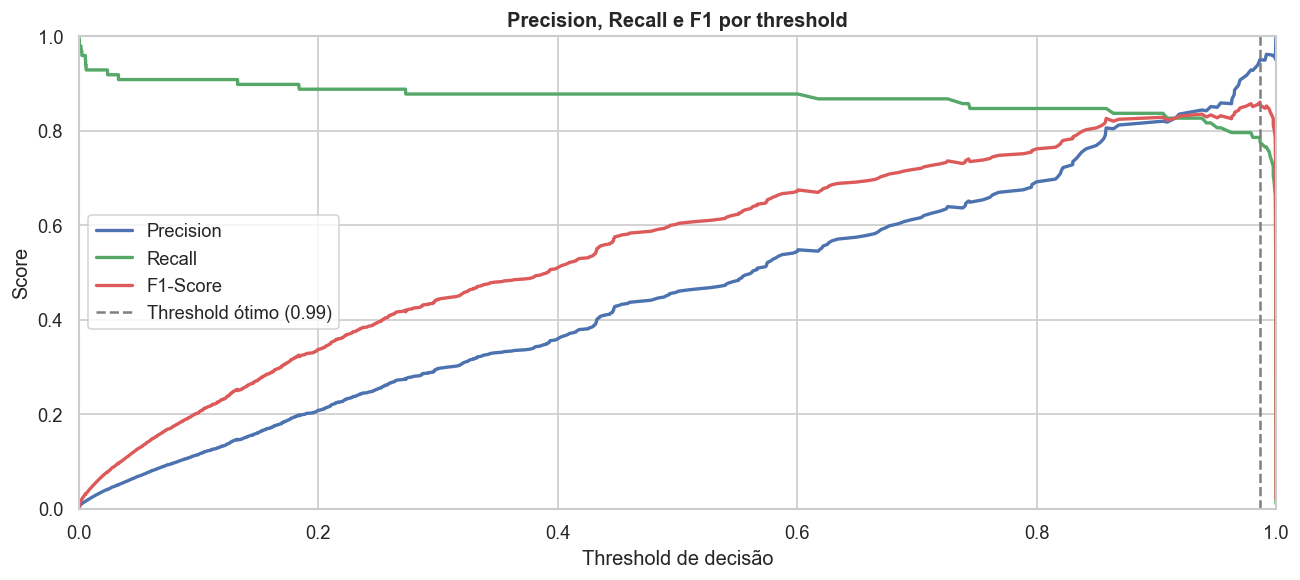

Threshold ótimo (máximo F1): 0.9866

Comparação de resultados:
Métrica   Threshold 0.5  Threshold ótimo
---------------------------------------------
Precision             0.4599           0.9506
Recall                0.8776           0.7857
F1-Score              0.6035           0.8603


In [204]:
from sklearn.metrics import precision_score, recall_score, f1_score
# precision e recall têm len(thresholds) + 1 — alinhar os arrays
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
optimal_idx = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(thresholds, precision[:-1], color='#4C72B0',
        linewidth=2, label='Precision')
ax.plot(thresholds, recall[:-1], color='#55A868',
        linewidth=2, label='Recall')
ax.plot(thresholds, f1_scores, color='#DD5A5A',
        linewidth=2, label='F1-Score')
ax.axvline(x=optimal_threshold, color='gray', linestyle='--',
         linewidth=1.5, label=f'Threshold ótimo ({optimal_threshold:.2f})')

ax.set_xlabel('Threshold de decisão')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall e F1 por threshold', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/figures/threshold_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# avaliar com threshold ótimo
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

print(f"Threshold ótimo (máximo F1): {optimal_threshold:.4f}")
print(f"\nComparação de resultados:")
print(f"{'Métrica':<2} {'Threshold 0.5':>15} {'Threshold ótimo':>16}")
print("-" * 45)

for metric, name in [
    ('precision', 'Precision'),
    ('recall', 'Recall'),
    ('f1', 'F1-Score')
]:
    
    fn_map = {
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    }
    val_default = fn_map[metric](y_test, y_pred_default)
    val_optimal = fn_map[metric](y_test, y_pred_optimal)
    print(f"{name:<12} {val_default:>15.4f} {val_optimal:>16.4f}")

### Escolha do threshold em produção

O threshold ótimo por F1 maximiza o equilíbrio entre Precision e Recall,
mas a escolha final depende do contexto de negócio:

- **Priorizar Recall alto** → threshold menor → detectar mais fraudes,
  mesmo bloqueando algumas transações legítimas
- **Priorizar Precision alta** → threshold maior → menos falsos alarmes,
  mas algumas fraudes passam

Em produção, essa decisão é tomada junto com a área de negócio com base
no custo relativo de cada tipo de erro.

### Interpretabilidade com SHAP

SHAP (SHapley Additive exPlanations) quantifica a contribuição de cada
feature para cada predição individual, respondendo "por que o modelo
classificou essa transação como fraude?".

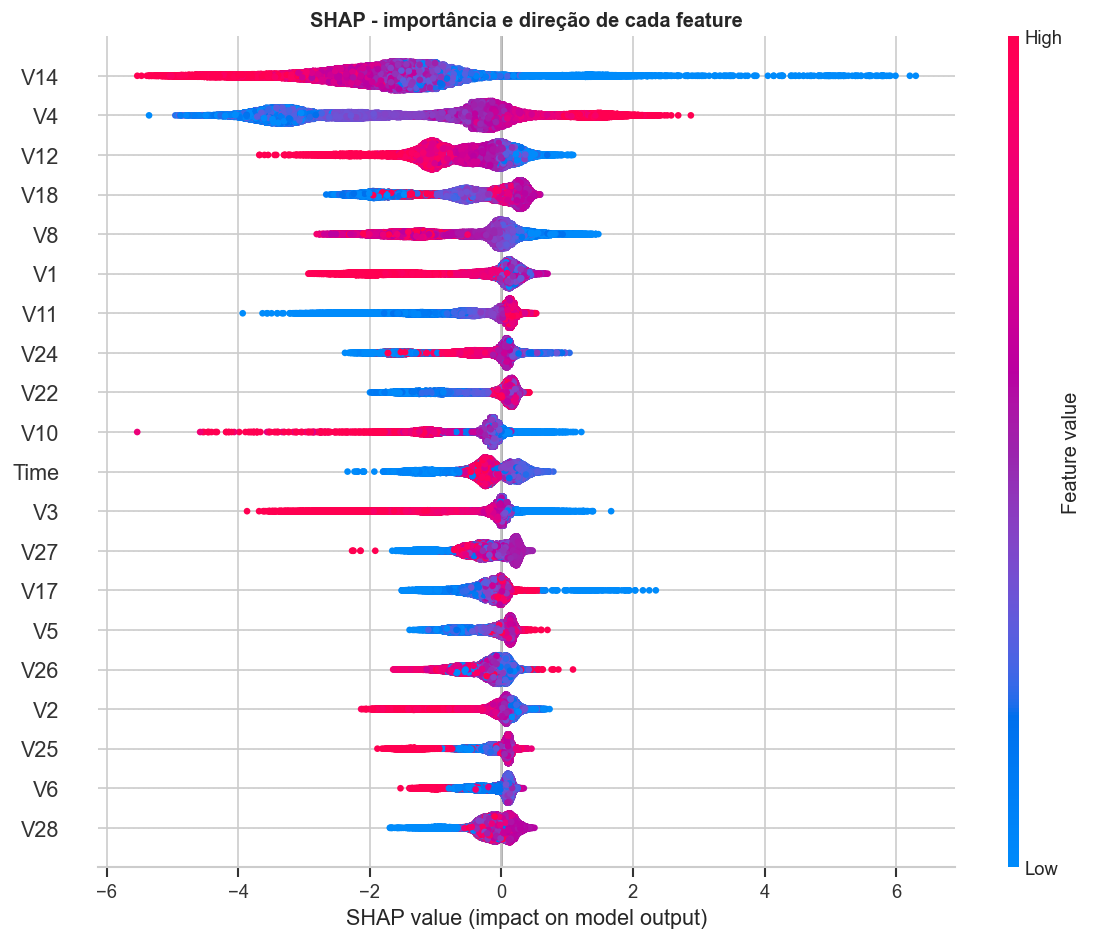

In [205]:
# extrair o modelo XGBoost de dentro do pipeline para SHAP
xgb_model = final_pipeline.named_steps['model']

# transformar X_test pelo preprocessor do pipeline (sem o SMOTE e o modelo)
preprocessor = final_pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)

# recupera nomes das features após ColumnTransformer
scaled_features = SCALE_FEATURES
passthrough_features = [col for col in X_train.columns if col not in SCALE_FEATURES]
feature_names = scaled_features + passthrough_features

# calcula os SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# sumary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False,
    plot_size=None
)
plt.title('SHAP - importância e direção de cada feature', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()